# How does meshing in MikFoil work?

This tutorial explains the core meshing algorithm in MikFoil. Note that many of the functions used here are strictly for demonstration and are not part of the main library.

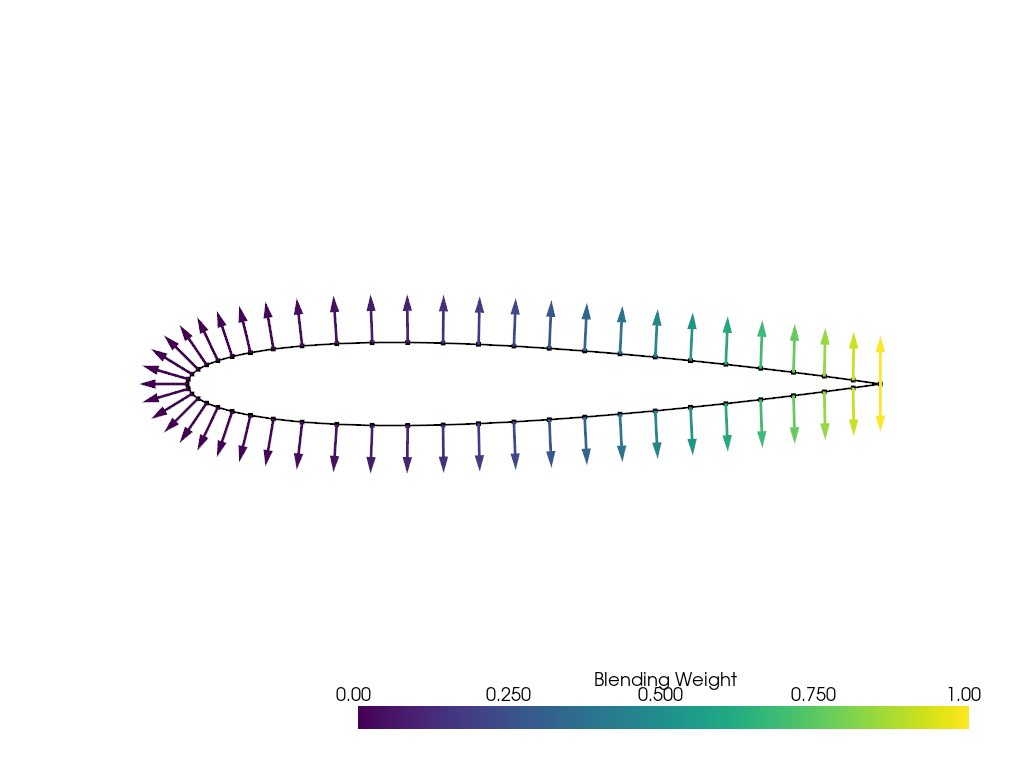

In [1]:
from mikfoil.case import MeshConfig
from mikfoil.geometry import create_airfoil
from mikfoil.meshing import visualize_mesh_interactive
from utils.Tutorial_04 import calculate_first_layer_height, plot_boundary_points, plot_mesh_splines, plot_growth_vectors

config = MeshConfig(fineness=1.0)
airfoil_geometry = create_airfoil("NACA0012", config)
plot_growth_vectors(airfoil_geometry)


We generate the airfoil geometry just like before. This is the first point of meshing and defines the points on airfoil surface from which the mesh will grow.

As for the direction in which mesh grows, at leading edge it is set to be normal to the surface in order to obtain minimal skewness in mesh.

At the trailing edge the direction of growth is constrained to be perfectly vertical at the trailing edge so we get a flat horizontal line to grow the wake from. This also solves the problem of computing the normals at the edges of the airfoil curve which is top and bottom of the trailing edge. 

We use a simple linear blending function to connect those two growth directions.

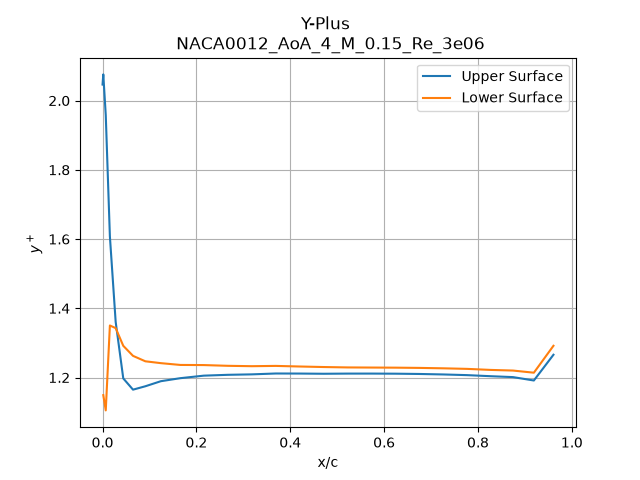

In [2]:
from mikfoil.case import Case, MeshConfig
from mikfoil.main import execute_case
from IPython.display import Image, display

mesh_config = MeshConfig()
case = Case(
    airfoil='NACA0012',
    aoa=4.0,
    mach=0.15,
    reynolds=3e6,
    mesh_config=mesh_config, 
    su2_config='default',
    project_dir='Tutorial_Cases/Tutorial_04',
    target_y_plus =1 #You can configure the target y plus by giving this argument
)

execute_case(case)

# Display the generated y+ plot
display(Image(filename=case.plots_dir / 'yplus.png'))



MikFoil works by specifying $y^+$ directly and calculates an estimate of first layer height from that value. This was tested and works quite well, so you can get a near perfect $y^+$ distribution automatically using Cf estimation from Schlichting's empirical correlation and calculating first layer height solving for it in $y^+$ definition.

$C_f = (2.0 \log_{10}(Re) - 0.65)^{-2.3}$

$H_1 = \frac{y^+}{Re \sqrt{C_f / 2.0}}$

>To accurately resolve the boundary layer, the $y^+$ must be close to 1, or if using wall functions in range from 30 to >300. By default MikFoil does not use wall functions so $y^+ = 1$. 


 






In [3]:
calculate_first_layer_height(y_plus=1.0, reynolds=1e6, chord=1.0)

Target y+: 1.0
Reynolds Number: 1.0e+06
Computed Skin Friction (Cf): 0.003745
Computed First Layer Height: 0.000023 meters


When using the MikFoil mesher standalone, MikFoil cannot guess your Reynolds number, so you can either:

- Specify `first_layer_height` directly in `MeshConfig`.
- Calculate first layer height using `calculate_first_layer_height` function as shown above

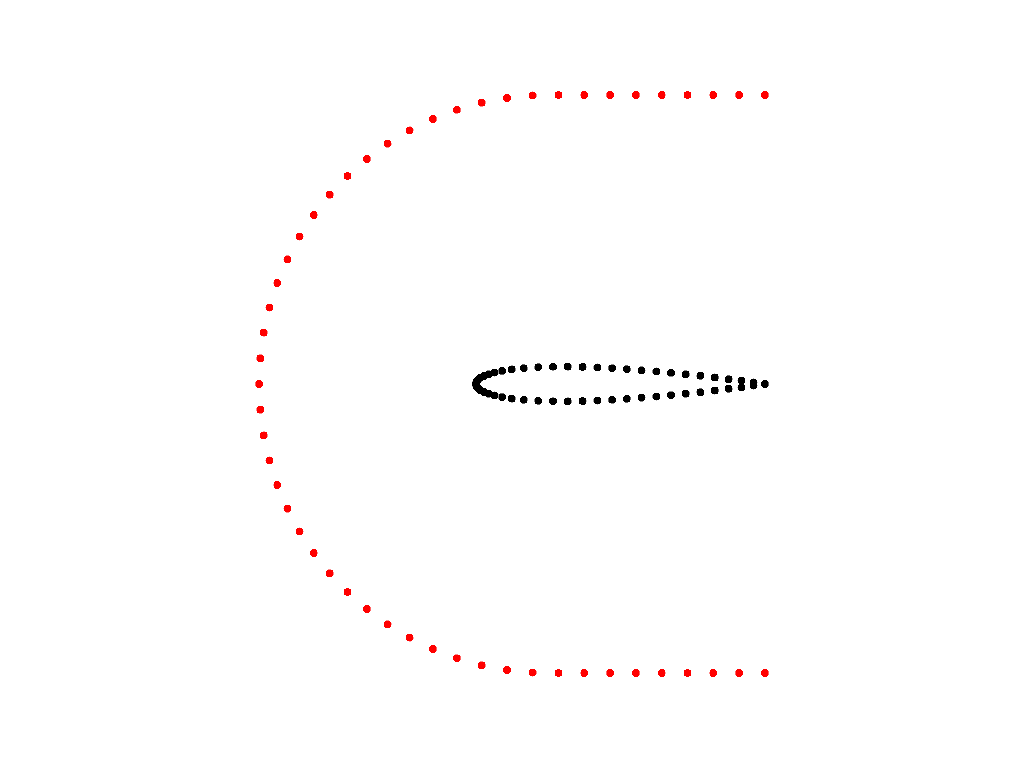

In [4]:
plot_config = MeshConfig(domain_radius=1.0, chord=1.0, use_normals=True)
plot_boundary_points(airfoil_geometry, plot_config)

The outer boundary has the same number of points as the number of them on the airfoil, they are set in place before any mesh generation begins. Points at the airfoil are distributed according to `s_le` `s_mid` and `s_te`. Points on the domain are distributed equally because that seems to give the nicest mesh and is simple.



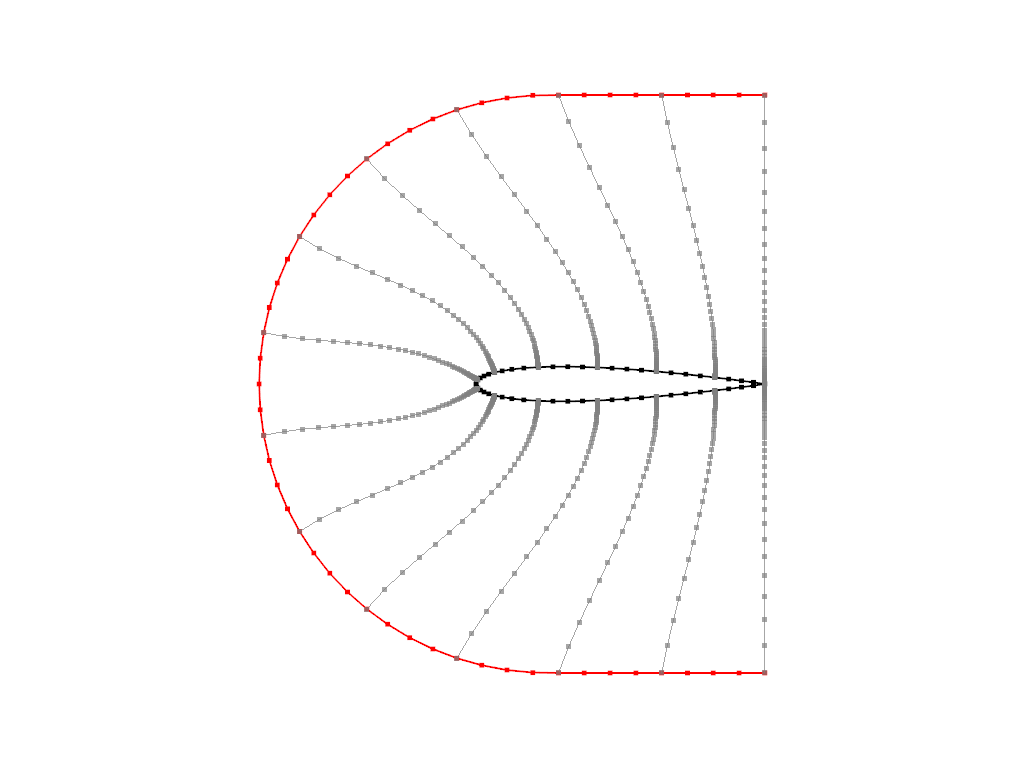

In [5]:
plot_mesh_splines(airfoil_geometry, plot_config)



MikFoil uses cubic splines to connect the points on the airfoil to those on the outer boundary. We constrain those splines to obey the growth vectors at the airfoil surface and be normal to the outer domain.



Grid points are distributed along these radial splines using geometric progression. The cell height starts exactly at the target $H_1$ and grows towards the farfield. [To ensure optimal cell quality at the outer boundary, this geometric growth is continuous across the entire domain. The algorithm calculates the precise growth rate required so that the final cell size exactly matches the tangential node spacing at the farfield boundary, resulting in nearly perfectly square cells at the outer edge.]

The wake region extends downstream from the trailing edge, growing geometrically in the flow direction. [Unlike the radial splines which are constrained by the farfield curve, the wake cells grow at a constant geometric rate until the total distance exactly hits the defined domain length boundary.]


We can now generate the full C-grid mesh and inspect it interactively.



In [6]:
import numpy as np
from mikfoil.meshing.airfoil_normals import get_airfoil_normals
from mikfoil.meshing.farfield_mesh import build_farfield_curve
from mikfoil.meshing.mesh_math import smooth_geometric_spacing
from mikfoil.meshing.interpolation import orthogonal_splines

# Assemble the ordered airfoil point array (same as generate_mesh internals)
upper_reversed = airfoil_geometry.upper_surface[::-1]
points = np.vstack([upper_reversed, airfoil_geometry.lower_surface[1:]])
chord = config.chord
radius = config.domain_radius

# Locate leading edge and build farfield
N_airfoil = len(points)
le_idx = int(np.argmin(points[:, 0]))
N_upper = le_idx + 1
N_lower = N_airfoil - le_idx
x_te = float(np.max(points[:, 0]))
x_ac = x_te - chord
farfield = build_farfield_curve(x_te, x_ac, radius, N_upper, N_lower)

# Radial distances and normals
D_vec = farfield - points
D_avg = float(np.mean(np.linalg.norm(D_vec, axis=1)))
s_tangent = float(np.mean(np.linalg.norm(np.diff(farfield, axis=0), axis=1)))
normals = get_airfoil_normals(points, chord)

# Calculate the geometric progression spacing
t = smooth_geometric_spacing(config.first_layer_height, s_tangent, D_avg)

# Interpolate using cubic Hermite splines enforced by normals
front_mesh = orthogonal_splines(points, farfield, normals, t, D_avg)


In [7]:
from mikfoil.meshing import generate_mesh

grid = generate_mesh(airfoil_geometry, config)

# Interactive PyVista visualization
visualize_mesh_interactive(grid)


Widget(value='<iframe src="http://localhost:62031/index.html?ui=P_0x1d6345f6210_2&reconnect=auto" class="pyvis…